# 02 — Target Generation

Build boundary/function activation curves and CTL token sequences.

## Setup

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(".."))
from utils.label_conversion import CLASSES
from utils.target_generation import (
    build_targets, boundary_curve, function_curves,
    TARGET_FPS, NATIVE_FPS, DOWNSAMPLE_FACTOR,
    seconds_to_target_frames,
)
print(f"Native FPS: {NATIVE_FPS:.2f}")
print(f"Target FPS: {TARGET_FPS:.2f}")
print(f"Downsample factor: {DOWNSAMPLE_FACTOR}")


Native FPS: 21.53
Target FPS: 5.38
Downsample factor: 4


## Load a sample song

In [2]:
MELSPEC_DIR = os.path.abspath("../data/harmonixset/melspecs")
SEGMENT_DIR = os.path.abspath("../data/harmonixset/dataset/segments")
SID = "0001_12step"
melspec = np.load(os.path.join(MELSPEC_DIR, f"{SID}-mel.npy"))
print(f"Melspec shape: {melspec.shape}")  # (80, T_native)
with open(os.path.join(SEGMENT_DIR, f"{SID}.txt"), encoding="utf-8", errors="replace") as f:
    lines = f.readlines()
print(f"Segments: {len(lines)}")
for l in lines[:8]:
    print(f"  {l.strip()}")


Melspec shape: (80, 3066)
Segments: 10
  0.0 intro
  8.495568 verse
  25.486704 chorus
  42.475328 verse
  59.47014 chorus
  78.594744 verse
  95.585708 chorus
  112.578716 chorus


## Build targets

In [3]:
boundaries = [0.0]
labels = []
with open(os.path.join(SEGMENT_DIR, f"{SID}.txt"), encoding="utf-8", errors="replace") as f:
    for line in f:
        parts = line.strip().split(maxsplit=1)
        if len(parts) == 2:
            boundaries.append(float(parts[0]))
            labels.append(parts[1].strip())
print(f"Song duration: {boundaries[-1]:.1f}s")
print(f"Number of segments: {len(labels)}")

b_curve, f_curves, token_seq = build_targets(boundaries, labels)
print(f"Boundary curve: {b_curve.shape}")
print(f"Function curves: {f_curves.shape}")
print(f"Token seq: {token_seq}")
print(f"Token sequence length: {len(token_seq)}")


Song duration: 138.1s
Number of segments: 10
Boundary curve: (743,)
Function curves: (743, 7)
Token seq: [0, 1, 2, 1, 2, 1, 2, 2, 4]
Token sequence length: 9


## Visualize boundary curve

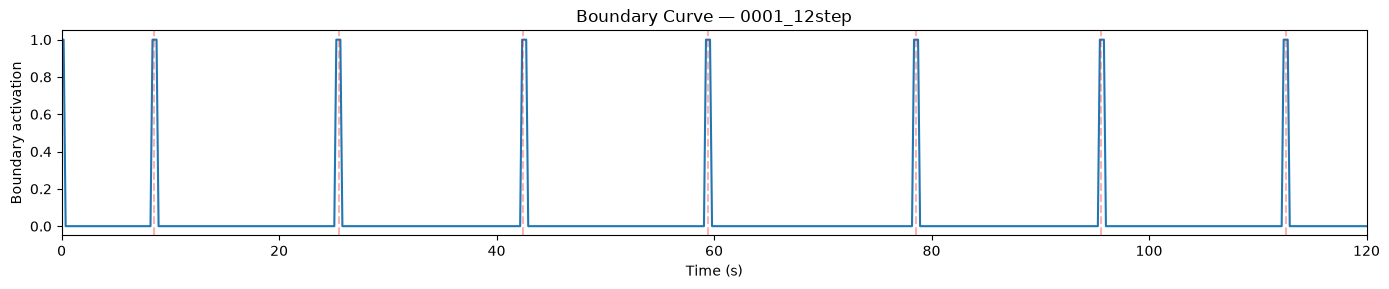

In [4]:
fig, ax = plt.subplots(figsize=(14, 3))
time_axis = np.arange(len(b_curve)) / TARGET_FPS
ax.plot(time_axis, b_curve)
for b in boundaries:
    ax.axvline(b, color="red", alpha=0.3, linestyle="--")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Boundary activation")
ax.set_title(f"Boundary Curve — {SID}")
ax.set_xlim(0, min(120, boundaries[-1]))
plt.tight_layout()
plt.show()


## Visualize function curves

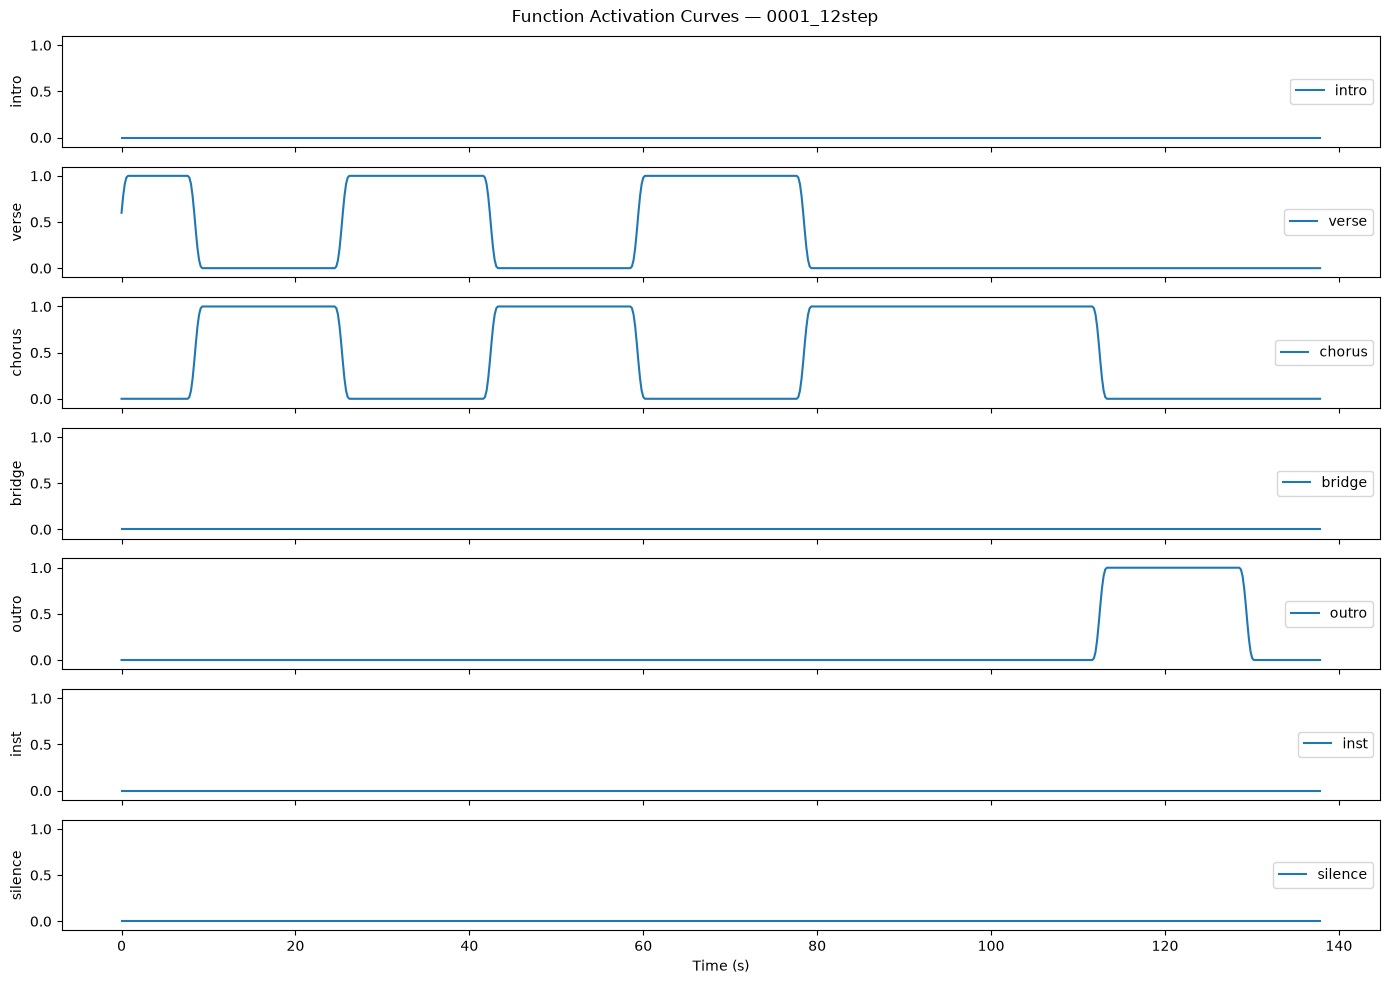

In [5]:
fig, axes = plt.subplots(7, 1, figsize=(14, 10), sharex=True)
for i, cls_name in enumerate(CLASSES):
    axes[i].plot(time_axis, f_curves[:, i], label=cls_name)
    axes[i].set_ylabel(cls_name)
    axes[i].set_ylim(-0.1, 1.1)
    axes[i].legend(loc="right")
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Function Activation Curves — {SID}")
plt.tight_layout()
plt.show()


## Overlay on mel spectrogram

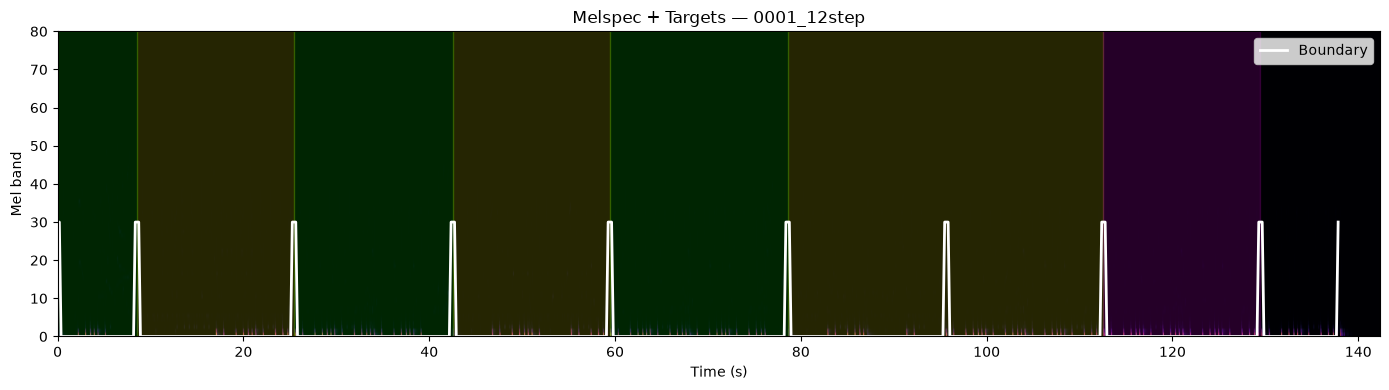

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
native_time = np.arange(melspec.shape[1]) / NATIVE_FPS
ax.imshow(melspec, aspect="auto", origin="lower",
          extent=[0, native_time[-1], 0, 80], cmap="magma")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mel band")

target_time = np.arange(len(b_curve)) / TARGET_FPS
scaled_curve = b_curve * 30  # scale for visibility
ax.plot(target_time, scaled_curve, "w-", linewidth=2, label="Boundary")

# Color overlay for each class
colors = ["cyan", "lime", "yellow", "orange", "magenta", "red", "blue"]
for i, cls_name in enumerate(CLASSES):
    mask = f_curves[:, i] > 0.5
    if mask.any():
        segments = []
        in_seg = False
        for t in range(len(mask)):
            if mask[t] and not in_seg:
                start = target_time[t]
                in_seg = True
            elif not mask[t] and in_seg:
                end = target_time[t]
                ax.axvspan(start, end, alpha=0.15, color=colors[i])
                in_seg = False
        if in_seg:
            ax.axvspan(start, target_time[-1], alpha=0.15, color=colors[i])
ax.legend()
ax.set_title(f"Melspec + Targets — {SID}")
plt.tight_layout()
plt.show()


## Downsampling sanity check

In [7]:
# Verify that native -> target conversion is consistent
native_frames = melspec.shape[1]
target_frames_from_native = native_frames // DOWNSAMPLE_FACTOR
target_frames_from_duration = int(round(boundaries[-1] * TARGET_FPS))
print(f"Native frames: {native_frames}")
print(f"Target frames (from native // {DOWNSAMPLE_FACTOR}): {target_frames_from_native}")
print(f"Target frames (from duration): {target_frames_from_duration}")
print(f"Actual target curve length: {len(b_curve)}")


Native frames: 3066
Target frames (from native // 4): 766
Target frames (from duration): 743
Actual target curve length: 743
